**04 – Network Analysis of Blocking on Bluesky**

- Model blocking as a directed network to understand:

- Structural concentration of blocking

- Who is most blocked vs who blocks the most

- Whether list-based blocking changes network topology

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import datetime as dt

In [2]:
blocks = pd.read_parquet("blocks.parquet")
blocks['created_date'] = pd.to_datetime(blocks['created_date'], errors='coerce')

# Focus on 2023+
blocks = blocks[blocks['created_date'] >= '2023-01-01']

Bluid a blocking graph

In [3]:
# top blockers and most-blocked users
TOP_K = 5000


top_blockers = blocks['did_id'].value_counts().head(TOP_K).index
top_blocked = blocks['subject_did_id'].value_counts().head(TOP_K).index


sub_blocks = blocks[
blocks['did_id'].isin(top_blockers) |
blocks['subject_did_id'].isin(top_blocked)
]

In [ ]:
# pick a narrow time window
blocks_slice = pd.read_parquet(
    "blocks.parquet",
    filters=[
        ("created_date", ">=", dt.date(2024, 1, 1)),
        ("created_date", "<",  dt.date(2024, 2, 1)),
    ],
    engine="pyarrow"
)

len(blocks_slice)

G = nx.from_pandas_edgelist(
    blocks_slice,
    source='did_id',
    target='subject_did_id',
    create_using=nx.DiGraph()
)

G.number_of_nodes(), G.number_of_edges()


(104355, 335279)

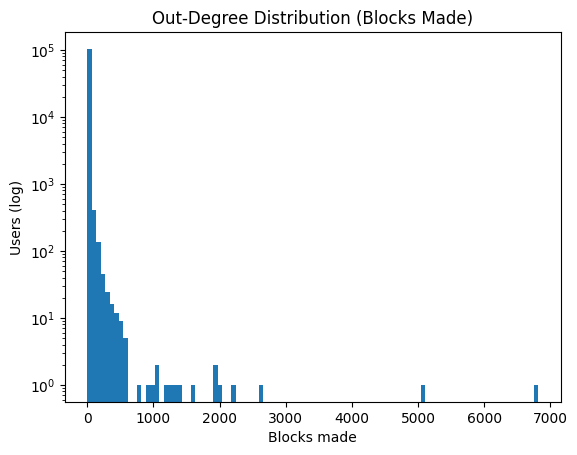

In [9]:
out_degrees = dict(G.out_degree())

plt.figure()
plt.hist(out_degrees.values(), bins=100, log=True)
plt.title('Out-Degree Distribution (Blocks Made)')
plt.xlabel('Blocks made')
plt.ylabel('Users (log)')
plt.show()

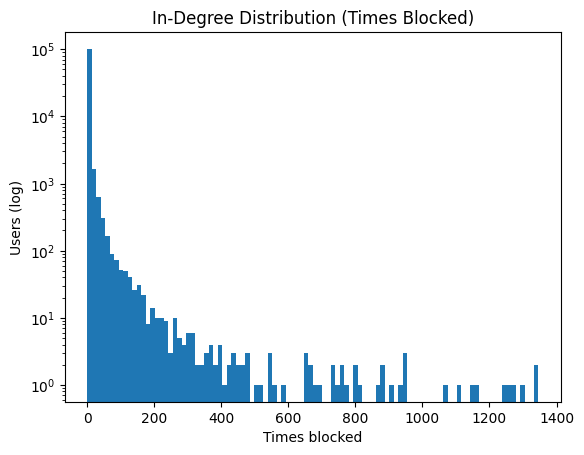

In [10]:
in_degrees = dict(G.in_degree())

plt.figure()
plt.hist(in_degrees.values(), bins=100, log=True)
plt.title('In-Degree Distribution (Times Blocked)')
plt.xlabel('Times blocked')
plt.ylabel('Users (log)')
plt.show()

Central actors

In [11]:
pd.Series(in_degrees).sort_values(ascending=False).head(20)

32178199    1345
6293249     1340
22762508    1293
13259696    1272
29267381    1264
2227742     1246
25813514    1160
10376308    1147
15236269    1104
16718480    1064
6827191      952
19458295     948
8251709      944
29191911     935
18616096     911
25422151     883
21975657     877
31090119     870
8938955      817
8361745      798
dtype: int64

In [12]:
pd.Series(out_degrees).sort_values(ascending=False).head(20)

20222892    6813
17655652    5089
4122594     2601
27737456    2232
24789886    1993
20416991    1959
13691402    1953
15837569    1598
2462768     1404
5873658     1295
28338561    1238
23911500    1186
11586570    1089
32872591    1039
15504389     994
21762420     899
9217497      805
25104901     581
31720337     581
26187105     565
dtype: int64

Connectivity and components

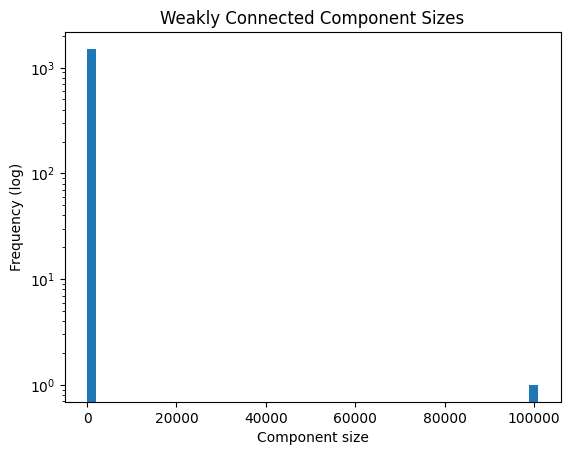

In [13]:
components = list(nx.weakly_connected_components(G))
component_sizes = [len(c) for c in components]

plt.figure()
plt.hist(component_sizes, bins=50, log=True)
plt.title('Weakly Connected Component Sizes')
plt.xlabel('Component size')
plt.ylabel('Frequency (log)')
plt.show()

Reciprocity

In [14]:
reciprocal_edges = sum(1 for u,v in G.edges() if G.has_edge(v,u))
reciprocity_rate = reciprocal_edges / G.number_of_edges()

reciprocity_rate

0.013773603476507626

Community structure

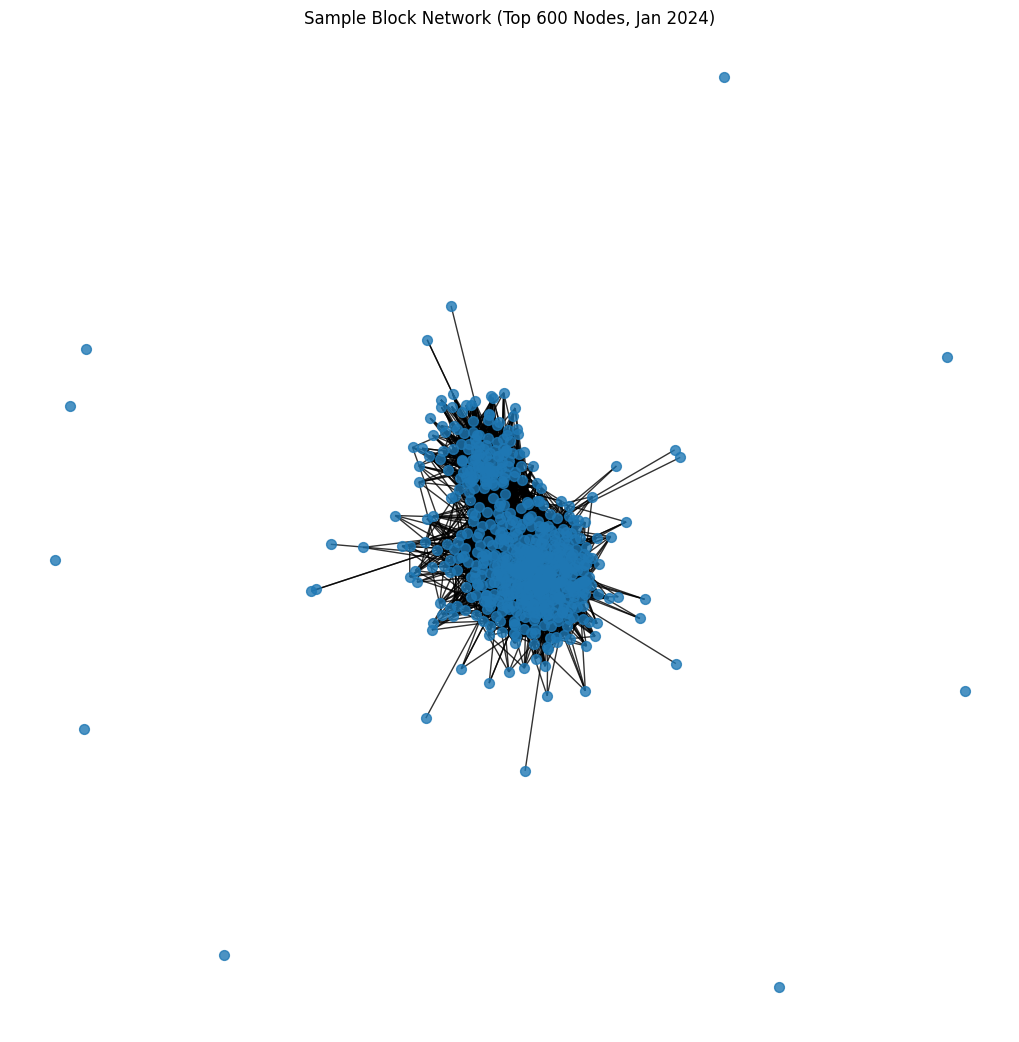

In [22]:
# get total degree (in + out)
degree = dict(G.degree())

# top 600 nodes by degree
top_nodes = sorted(degree, key=degree.get, reverse=True)[:600]

# induce subgraph
G_small = G.subgraph(top_nodes).copy()

len(G_small.nodes()), len(G_small.edges())
plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G_small, seed=42, k=0.5)

nx.draw(
    G_small,
    pos,
    node_size=50,
    alpha=0.8,
    arrows=False
)

plt.title("Sample Block Network (Top 600 Nodes, Jan 2024)")
plt.show()
